In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy import stats
from scipy.stats import ttest_rel

import scienceplots

In [ ]:
np.mean(
    [
        0.48,
        0.4,
        0.52,
        0.38,
        0.38,
        0.64,
        0.52,
        0.48,
        0.34,
        0.42,
        0.36,
        0.38,
        0.44,
        0.38,
        0.52,
        0.3,
        0.38,
        0.5,
        0.28,
        0.34,
        0.52,
        0.38,
        0.4,
        0.38,
        0.32,
        0.6,
        0.34,
        0.42,
        0.32,
        0.44,
        0.48,
        0.48,
        0.46,
        0.48,
        0.38,
        0.3,
        0.44,
        0.62,
        0.48,
        0.52,
        0.5,
        0.6,
        0.42,
        0.36,
        0.5,
        0.26,
        0.36,
        0.4,
        0.36,
        0.4,
        0.4,
        0.58,
        0.46,
        0.52,
        0.42,
        0.44,
        0.5,
        0.42,
        0.38,
        0.42,
        0.48,
        0.62,
        0.38,
        0.38,
        0.44,
        0.5,
        0.4,
        0.7,
        0.4,
        0.3,
        0.46,
        0.66,
        0.52,
        0.48,
        0.68,
        0.64,
        0.46,
        0.54,
        0.5,
        0.54
    ]
)

In [2]:
DARK_BLUE  = (0.0, 0.4667, 0.7333)
LIGHT_BLUE = (0.2, 0.7333, 0.9333)
GREEN      = (0.0, 0.6, 0.5333)
ORANGE     = (0.9333, 0.4667, 0.2)
RED        = (0.8, 0.2, 0.0667)
PINK       = (0.9333, 0.2, 0.4667)
GRAY       = (0.7333, 0.7333, 0.7333)

SAVE = False

In [3]:
RUNS = {
    "Rest": 
    {
        "folder": '/Users/juliuswuerzler/Desktop/2Pong/New/New Pong/THESIS/02_13_00_16_trial_NT_OLDTP_Var02_300s_30Hz_yEnc_RST',
        "color": GRAY
    },
    "!FB": 
    {
        "folder": '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_21_09_24_LR1e4_PW_04_nofb',
        "color": DARK_BLUE
    },
    "FB": 
    {
        "folder": '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_21_12_04_LR1e4_PW_04',
        "color": ORANGE
    }
}

In [4]:
def ema(x, alpha=0.1):
    y = np.zeros_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y


def average_rally_length(arr):
    arr = np.asarray(arr)
    zero_idx = np.where(arr == 0)[0]
    
    if len(zero_idx) == 0:
        return len(arr)
    
    return np.sum(arr) / len(zero_idx)


def long_rallies(arr):
    arr = np.asarray(arr)
    zero_idx = np.where(arr == 0)[0]
    
    if len(zero_idx) == 0:
        return float(len(arr) >= 3)
    
    prev_zero = np.concatenate(([-1], zero_idx[:-1]))
    lengths = zero_idx - prev_zero - 1
    return np.mean(lengths >= 3)


def aces(arr):
    arr = np.asarray(arr)
    zero_idx = np.where(arr == 0)[0]
    
    if len(zero_idx) == 0:
        return 0.0  # Fixed: return scalar, not array
    
    prev_zero_idx = np.concatenate(([-1], zero_idx[:-1]))
    lengths = zero_idx - prev_zero_idx - 1
    return np.mean(lengths == 0)

In [5]:
# Configuration
ALPHA = 0.05
N = 50

# Define metrics to compute
METRICS = {
    'Aces': {'func': aces, 'scale': 100},
    'RL': {'func': average_rally_length, 'scale': 1},
    'LR': {'func': long_rallies, 'scale': 100}
}

# Process each run
for run in RUNS:
    result_files = glob.glob(os.path.join(RUNS[run]['folder'], "*results.csv"))
    RUNS[run]['results'] = {}
    
    # Initialize collectors
    rolling_means = []
    start_end_collectors = {'start': [], 'end': []}
    metric_collectors = {
        metric: {'start': [], 'end': []} 
        for metric in METRICS
    }
    
    # Process each network file
    for f in result_files:
        network = f.split('_')[-2]
        results = np.loadtxt(f)
        RUNS[run]['results'][network] = {}
        
        # Rolling mean
        smoothed_results = ema(results, ALPHA)
        RUNS[run]['results'][network]['rolling means'] = smoothed_results
        rolling_means.append(smoothed_results)
        
        # Start and end performance
        start_results = np.mean(results[:N])
        end_results = np.mean(results[-N:])
        RUNS[run]['results'][network]['s'] = start_results
        RUNS[run]['results'][network]['e'] = end_results
        start_end_collectors['start'].append(start_results)
        start_end_collectors['end'].append(end_results)
        
        # Compute all metrics
        for metric_name, metric_config in METRICS.items():
            func = metric_config['func']
            scale = metric_config['scale']
            
            RUNS[run]['results'][network][metric_name] = {}
            start_val = func(results[:N]) * scale
            end_val = func(results[-N:]) * scale
            
            RUNS[run]['results'][network][metric_name]['s'] = start_val
            RUNS[run]['results'][network][metric_name]['e'] = end_val
            
            metric_collectors[metric_name]['start'].append(start_val)
            metric_collectors[metric_name]['end'].append(end_val)
    
    # Store aggregated results
    RUNS[run]['rolling means'] = np.array(rolling_means)
    RUNS[run]['start'] = np.array(start_end_collectors['start'])
    RUNS[run]['end'] = np.array(start_end_collectors['end'])
    
    for metric_name in METRICS:
        RUNS[run][metric_name] = {
            'start': np.array(metric_collectors[metric_name]['start']),
            'end': np.array(metric_collectors[metric_name]['end'])
        }

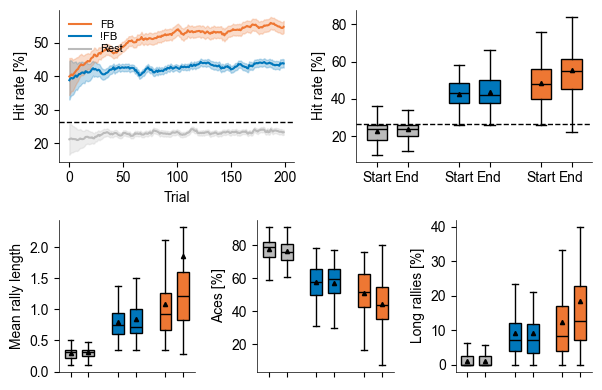

In [8]:
plt.style.use(['nature_d'])
fig, axs = plt.subplot_mosaic(
    [
        ["OT", "OT", "OT", "SvE", "SvE", "SvE"],
        ["RL", "RL", "Aces", "Aces", "LR", "LR"]
    ],
    sharey=False
)

# Plot configuration
BOXPLOT_CONFIG = {
    'widths': 0.5,
    'patch_artist': True,
    'showfliers': False,
    'showmeans': True,
    'meanprops': {
        "markerfacecolor": 'black',
        "markeredgecolor": 'black',
        "markersize": 3
    }
    
}

axs['OT'].axhline(25/95 * 100, linestyle='--', color='black', linewidth=1)#, label='Chance')
axs['SvE'].axhline(25/95 * 100, linestyle='--', color='black', linewidth=1)#, label='Chance')

METRIC_AXES = ['RL', 'Aces', 'LR']

for i, run in enumerate(RUNS):
    data = RUNS[run]['rolling means']* 100
    color = RUNS[run]['color']
    
    # Plot rolling mean with SEM
    _mean = data.mean(axis=0) 
    sem = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])
    x = np.arange(len(_mean))
    
    axs["OT"].plot(x, _mean, color=color, alpha=1.0, linewidth=1.5, 
                   label=f'{run}') # (n={len(data)})
    axs["OT"].fill_between(x, _mean - sem, _mean + sem, color=color, alpha=0.25)
    
    # Helper function to style boxplot
    def style_boxplot(box_parts, color):
        for box in box_parts['boxes']:
            box.set_facecolor(color)
            box.set_edgecolor('black')
        for element in ['whiskers', 'caps', 'medians']:
            for item in box_parts[element]:
                item.set_color('black')
                item.set_linewidth(1)
    
    # Plot start/end boxplots for main metric
    for offset, period in enumerate(['start', 'end']):
        box_parts = axs["SvE"].boxplot(
            RUNS[run][period] * 100,
            positions=[i*2 + offset*0.75],
            **BOXPLOT_CONFIG
        )
        style_boxplot(box_parts, color)
    
    # Plot metric boxplots
    for metric_ax in METRIC_AXES:
        for offset, period in enumerate(['start', 'end']):
            box_parts = axs[metric_ax].boxplot(
                RUNS[run][metric_ax][period],
                positions=[i*2 + offset*0.75],
                **BOXPLOT_CONFIG
            )
            style_boxplot(box_parts, color)

# Styling
handles, labels = axs['OT'].get_legend_handles_labels()
axs['OT'].legend(handles[::-1], labels[::-1], labelspacing=0.2, loc='upper left')

# Axis labels
axs["OT"].set_xlabel('Trial')
# axs["OT"].set_ylim([16, 43.5])
axs["OT"].set_ylabel('Hit rate [%]')
axs["SvE"].set_ylabel('Hit rate [%]')

# Set x-tick labels
for ax_name in ['RL', 'Aces', 'LR']:
    axs[ax_name].set_xticklabels([])
for ax_name in ['SvE']:
    axs[ax_name].set_xticklabels([x for _ in range(len(RUNS)) for x in ["Start", "End"]])
# for ax_name in METRIC_AXES:
#     axs[ax_name].set_xticklabels([x for _ in range(len(RUNS)) for x in [r"$t_s$", r"$t_e$"]])

# Y-axis labels for metrics
axs["RL"].set_ylabel('Mean rally length')
axs["Aces"].set_ylabel('Aces [%]')
axs["LR"].set_ylabel('Long rallies [%]')

# Adjust figure size
w, h = fig.get_size_inches()
fig.set_size_inches(w, 4)

fig.tight_layout()
if SAVE:
    fig.savefig("fig_1_performance.pdf", dpi=300)
plt.show()

In [7]:
s = np.asarray(RUNS['No feedback']['start'], dtype=float)
e = np.asarray(RUNS['No feedback']['start'], dtype=float)
if s.shape != e.shape:
    raise ValueError(f"Shape mismatch: s_acc {s.shape} vs e_acc {e.shape}")

# Per-seed improvement (end - start)
d = e - s
n = d.size
df = n - 1

mean_s = s.mean()
mean_e = e.mean()
mean_diff = d.mean()
sd_diff = d.std(ddof=1)
se_diff = sd_diff / np.sqrt(n)

# Paired t-test
# Two-sided (default)
t_stat_2s, p_val_2s = ttest_rel(e, s)  # tests mean(e - s) != 0

# One-sided p-value for "improved" (mean(e - s) > 0)
# (Works regardless of SciPy version)
p_val_1s = p_val_2s / 2 if t_stat_2s > 0 else 1 - (p_val_2s / 2)

# 95% CI for mean improvement (two-sided)
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df=df)
ci_low = mean_diff - t_crit * se_diff
ci_high = mean_diff + t_crit * se_diff

# Effect size: Cohen's d for paired samples (a.k.a. dz)
# dz = mean(diff) / sd(diff)
cohens_dz = mean_diff / sd_diff if sd_diff > 0 else np.inf

# Optional: Hedges' g correction for small n (paired analogue)
J = 1 - (3 / (4 * df - 1)) if df > 1 else 1.0
hedges_gz = J * cohens_dz

print("Paired comparison (per seed): end - start")
print(f"n = {n}")
print(f"start: mean = {mean_s:.6f}, end: mean = {mean_e:.6f}")
print(f"diff (end-start): mean = {mean_diff:.6f}, sd = {sd_diff:.6f}, se = {se_diff:.6f}")
print(f"t({df}) = {t_stat_2s:.6f}")
print(f"p (two-sided) = {p_val_2s:.6g}")
print(f"p (one-sided, improved) = {p_val_1s:.6g}")
print(f"95% CI for mean diff = [{ci_low:.6f}, {ci_high:.6f}]")
print(f"Cohen's dz = {cohens_dz:.6f}")
print(f"Hedges' gz (small-sample corrected) = {hedges_gz:.6f}")

KeyError: 'No feedback'